In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
pd.set_option('display.max_columns',None)
pd.set_option('display.max_rows',None)

In [58]:
df = pd.read_csv('smartphone_cleaned_v5.csv')

In [5]:
df.shape

(966, 25)

In [52]:
df.head()

,brand_name,model,price,rating,has_5g,has_nfc,has_ir_blaster,processor_brand,num_cores,processor_speed,battery_capacity,fast_charging_available,fast_charging,ram_capacity,internal_memory,screen_size,refresh_rate,resolution,num_rear_cameras,num_front_cameras,os,primary_camera_rear,primary_camera_front,extended_memory_available,extended_upto
0,oneplus,OnePlus 11 5G,54999.0,89.0,True,True,False,snapdragon,8.0,3.2,5000.0,1,100.0,12.0,256.0,6.70,120.0,1440 x 3216,3,1,android,50.0,16.0,0,NaN
1,oneplus,OnePlus Nord CE 2 Lite 5G,19989.0,81.0,True,False,False,snapdragon,8.0,2.2,5000.0,1,33.0,6.0,128.0,6.59,120.0,1080 x 2412,3,1,android,64.0,16.0,1,1024.0
2,samsung,Samsung Galaxy A14 5G,16499.0,75.0,True,False,False,exynos,8.0,2.4,5000.0,1,15.0,4.0,64.0,6.60,90.0,1080 x 2408,3,1,android,50.0,13.0,1,1024.0
3,motorola,Motorola Moto G62 5G,14999.0,81.0,True,False,False,snapdragon,8.0,2.2,5000.0,1,NaN,6.0,128.0,6.55,120.0,1080 x 2400,3,1,android,50.0,16.0,1,1024.0
4,realme,Realme 10 Pro Plus,24999.0,82.0,True,False,False,dimensity,8.0,2.6,5000.0,1,67.0,6.0,128.0,6.70,120.0,1080 x 2412,3,1,android,108.0,16.0,0,NaN


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 966 entries, 0 to 965
Data columns (total 25 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   brand_name                 966 non-null    object 
 1   model                      966 non-null    object 
 2   price                      966 non-null    float64
 3   rating                     870 non-null    float64
 4   has_5g                     966 non-null    bool   
 5   has_nfc                    966 non-null    bool   
 6   has_ir_blaster             966 non-null    bool   
 7   processor_brand            946 non-null    object 
 8   num_cores                  960 non-null    float64
 9   processor_speed            924 non-null    float64
 10  battery_capacity           955 non-null    float64
 11  fast_charging_available    966 non-null    int64  
 12  fast_charging              760 non-null    float64
 13  ram_capacity               966 non-null    float64

### Exploratory Data Analysis - 

#### Uni-Variate Analysis

We will proceed in a column-wise fashion

Text(0.5, 1.0, 'Top 5 Brands')

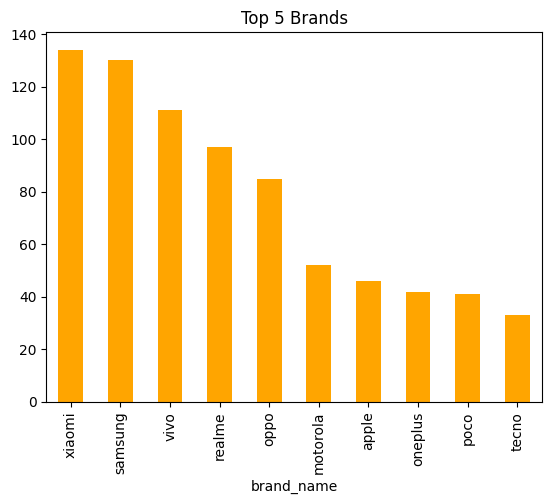

In [9]:
# top brands plot 
df['brand_name'].value_counts().head(10).plot(kind='bar', color='orange')
plt.title('Top 5 Brands')

<Axes: ylabel='count'>

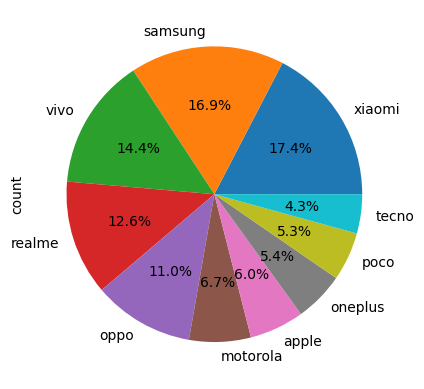

In [14]:
# pie chart 
df['brand_name'].value_counts().head(10).plot(kind='pie', autopct = '%1.1f%%')

In [ ]:
df['brand_name'].isnull().sum()

np.int64(0)

In [ ]:
df['model'].nunique()
# each phone is a unique entity  

966

In [ ]:
# bar plot top earners
df['price'].describe()
# mean - very high - indicates presence of outliers
# std - again very high
# median - seems alright but clear deviation from mean - skewed distribution
# max - 6.5 lakhs - crazy big value 

count       966.000000
mean      31657.525880
std       38783.684474
min        3499.000000
25%       12999.000000
50%       19990.000000
75%       34999.000000
max      650000.000000
Name: price, dtype: float64

In [ ]:
df['price'].skew()
# not at all normal distribution - very high skewness

np.float64(7.004427889924124)

<Axes: xlabel='price', ylabel='Count'>

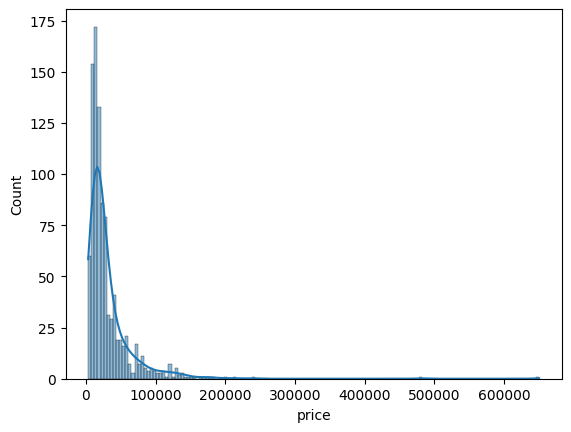

In [4]:
sns.histplot(df['price'], kde = True)

<Axes: xlabel='price'>

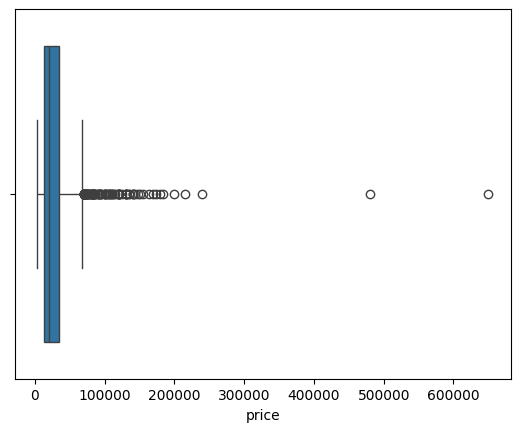

In [ ]:
sns.boxplot(x = df['price'])
# now, let's study the outliers

In [ ]:
df[df['price']>= 200000]
# checking these phones on web - they are real, luxury and expensive phones
# these are outliers as they will affect our prediction model performance (to be made later on)

,brand_name,model,price,rating,has_5g,has_nfc,has_ir_blaster,processor_brand,num_cores,processor_speed,...,screen_size,refresh_rate,resolution,num_rear_cameras,num_front_cameras,os,primary_camera_rear,primary_camera_front,extended_memory_available,extended_upto
422,vertu,Vertu Signature Touch,650000.0,62.0,False,True,False,snapdragon,8.0,1.50,...,4.70,60.0,1080 x 1920,1,1,android,13.0,2.1,0,NaN
473,huawei,Huawei Mate 50 RS Porsche Design,239999.0,81.0,False,True,True,snapdragon,8.0,3.20,...,6.74,120.0,1212 x 2616,3,1,other,50.0,13.0,1,256.0
874,xiaomi,Xiaomi Redmi K20 Pro Signature Edition,480000.0,88.0,False,True,False,snapdragon,8.0,2.80,...,6.39,60.0,1080 x 2340,3,1,android,48.0,20.0,0,NaN
938,huawei,Huawei Mate 30 RS Porsche Design,214990.0,NaN,True,True,True,kirin,8.0,2.86,...,6.53,60.0,1176 x 2400,4,2,android,40.0,32.0,1,256.0


In [8]:
df['price'].isnull().sum()

np.int64(0)

In [9]:
df['rating'].describe()

count    870.000000
mean      78.168966
std        7.385035
min       60.000000
25%       74.000000
50%       80.000000
75%       84.000000
max       89.000000
Name: rating, dtype: float64

In [ ]:
df['rating'].skew()
# closer to zreo - near to normal distribution

np.float64(-0.6945850816176975)

<Axes: xlabel='rating', ylabel='Count'>

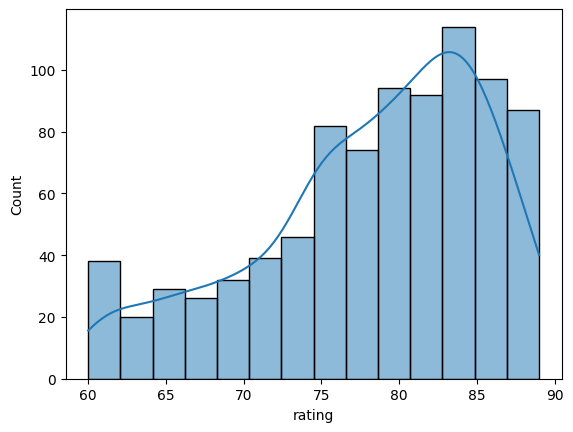

In [ ]:
sns.histplot(df['rating'], kde = True)
# seems near to normal curve

<Axes: xlabel='rating'>

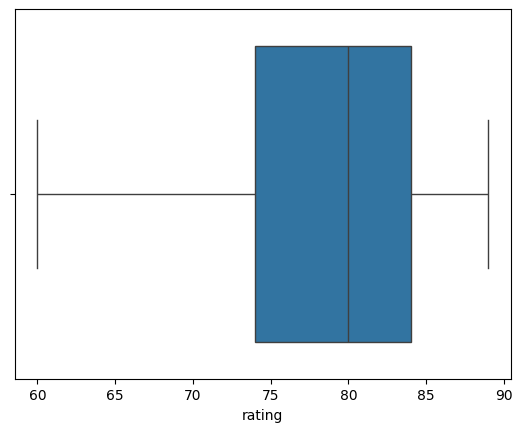

In [ ]:
sns.boxplot(x = df['rating'])
# no outliers

In [ ]:
df['rating'].isnull().sum()*100/966
# this is the major problem here ~10% missing values

np.float64(9.937888198757763)

<Axes: ylabel='count'>

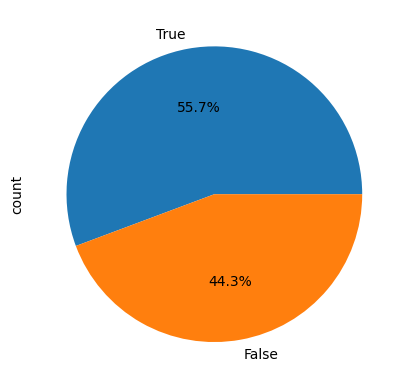

In [ ]:
# has 5g/ nfc/ ir blaster all are categorical columns 
df['has_5g'].value_counts().plot(kind='pie', autopct = '%0.1f%%')

# this col would be useful in prediction clearly

<Axes: ylabel='count'>

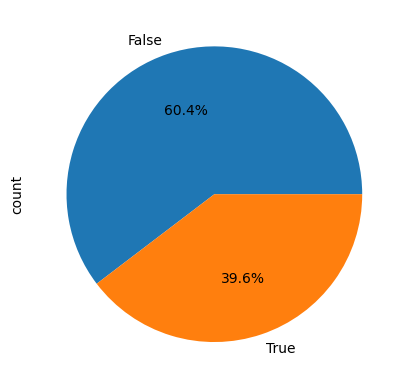

In [21]:
df['has_nfc'].value_counts().plot(kind='pie', autopct = '%0.1f%%')

<Axes: ylabel='count'>

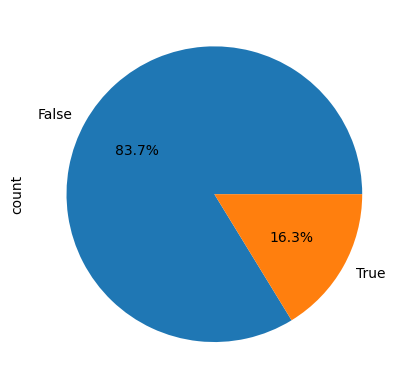

In [20]:
df['has_ir_blaster'].value_counts().plot(kind='pie', autopct = '%0.1f%%')

In [ ]:
df[df['has_ir_blaster'] == True]['brand_name'].value_counts()
# xiamoi, poco(sub-brand of xiaomi) mainly provide ir blaster feature in phones

brand_name
xiaomi     109
poco        30
iqoo         6
vivo         4
huawei       4
redmi        2
honor        1
samsung      1
Name: count, dtype: int64

<Axes: ylabel='count'>

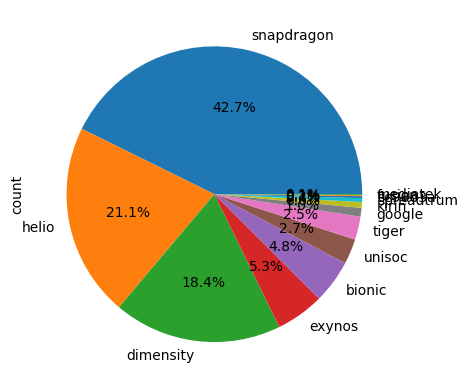

In [27]:
df['processor_brand'].value_counts().plot(kind='pie', autopct = '%0.1f%%')

<Axes: ylabel='count'>

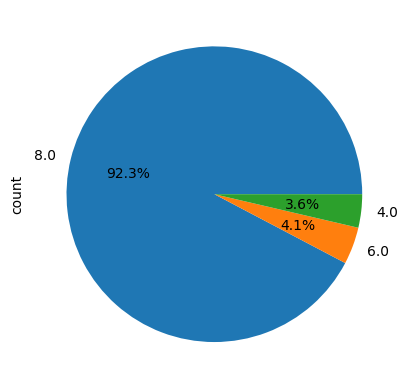

In [ ]:
df['num_cores'].value_counts().plot(kind='pie', autopct = '%0.1f%%')
# not much variety, most phones have octa-core processors
# not very useful while prediction

<Axes: ylabel='count'>

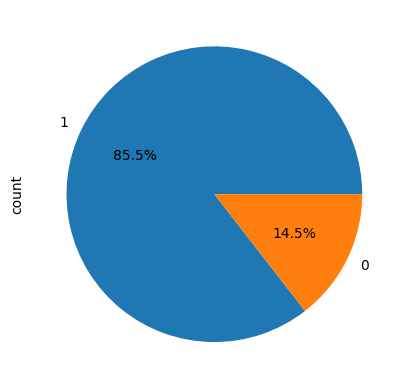

In [30]:
df['fast_charging_available'].value_counts().plot(kind='pie', autopct = '%0.1f%%') 

<Axes: ylabel='count'>

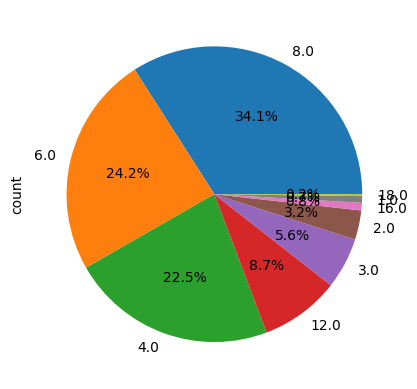

In [31]:
df['ram_capacity'].value_counts().plot(kind='pie', autopct = '%0.1f%%')

<Axes: ylabel='count'>

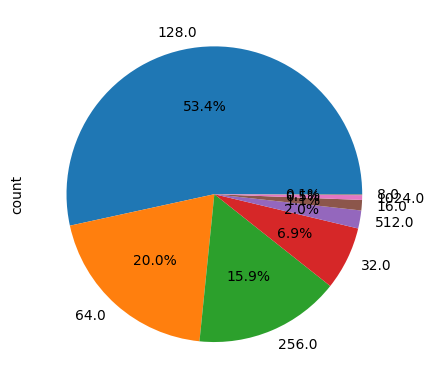

In [32]:
df['internal_memory'].value_counts().plot(kind='pie', autopct = '%0.1f%%')

<Axes: ylabel='count'>

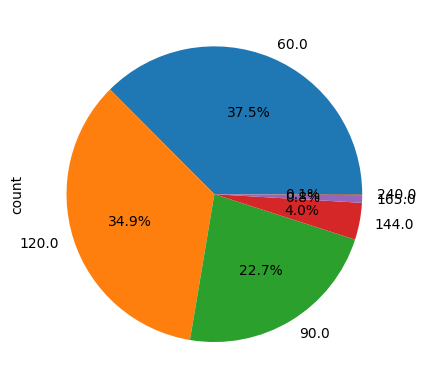

In [34]:
df['refresh_rate'].value_counts().plot(kind='pie', autopct = '%0.1f%%')

In [35]:
df['refresh_rate'].value_counts()

refresh_rate
60.0     362
120.0    337
90.0     219
144.0     39
165.0      8
240.0      1
Name: count, dtype: int64

In [59]:
df['num_front_cameras'].value_counts()

num_front_cameras
1          935
2           28
Missing      3
Name: count, dtype: int64

In [ ]:
df['num_front_cameras'] = pd.to_numeric(df['num_front_cameras']).fillna(0).astype(int)

In [ ]:
df['num_front_cameras'].value_counts()

num_front_cameras
1    935
2     28
0      3
Name: count, dtype: int64

<Axes: ylabel='count'>

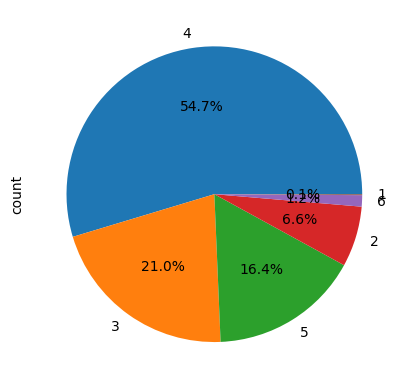

In [75]:
(df['num_front_cameras']+df['num_rear_cameras']).value_counts().plot(kind='pie', autopct = '%0.1f%%')

<Axes: ylabel='count'>

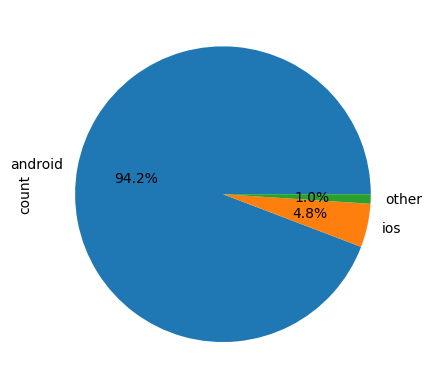

In [ ]:
df['os'].value_counts().plot(kind='pie', autopct = '%0.1f%%')
# andriod is the dominator 

<Axes: ylabel='count'>

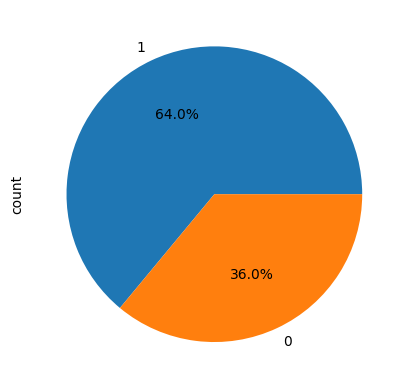

In [77]:
df['extended_memory_available'].value_counts().plot(kind='pie', autopct = '%0.1f%%')

<Axes: ylabel='count'>

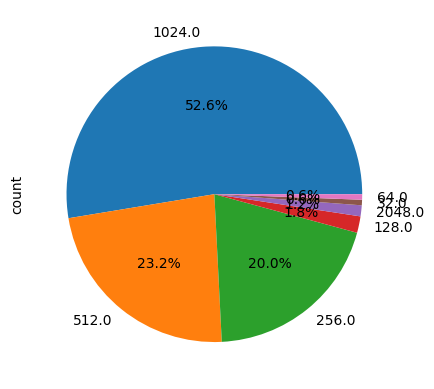

In [78]:
df['extended_upto'].value_counts().plot(kind='pie', autopct = '%0.1f%%')

In [ ]:
def plot_graphs(column_name):

  sns.displot(kind='hist',kde=True,data=df,x=column_name,label=column_name)
  sns.catplot(kind='box',data=df,x=column_name)

# done for faster plotting

In [81]:
num_columns = df.select_dtypes(include=['float64','int64']).iloc[:,[3,4,6,9,13,14,16]].columns

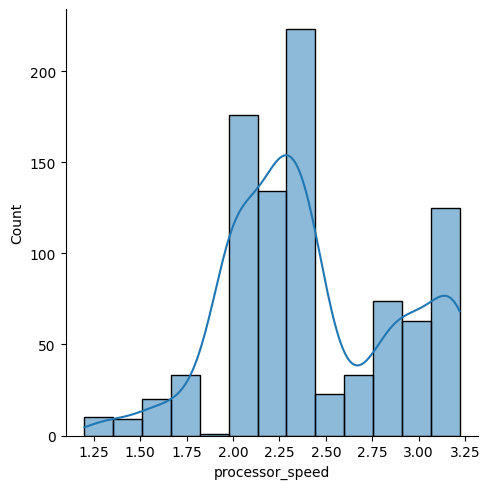

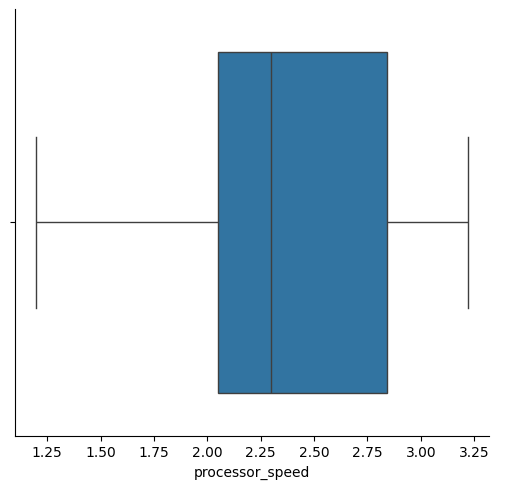

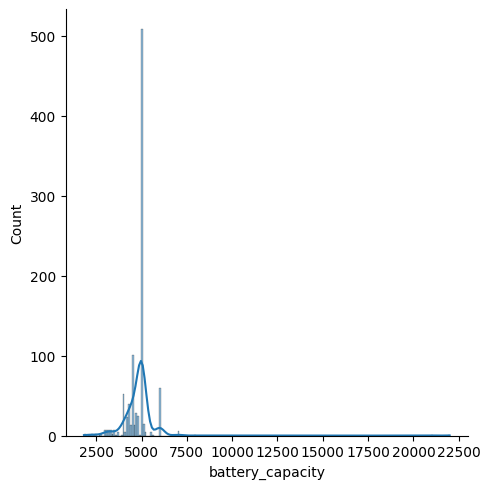

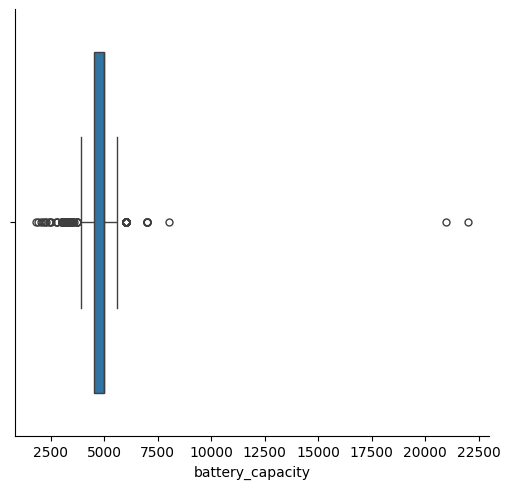

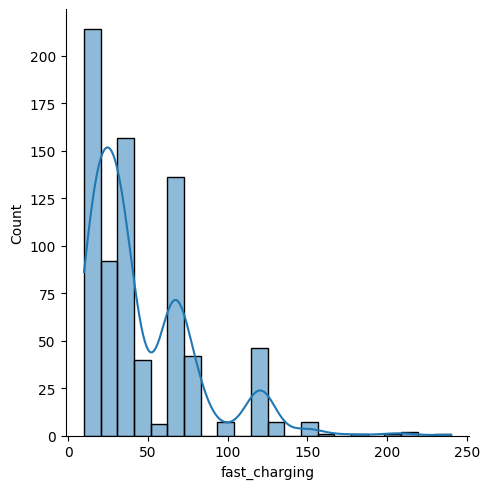

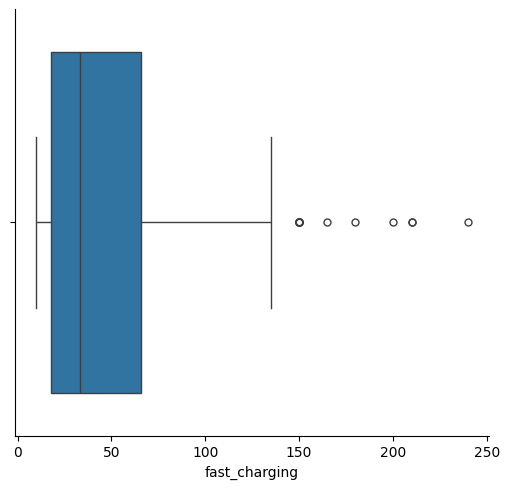

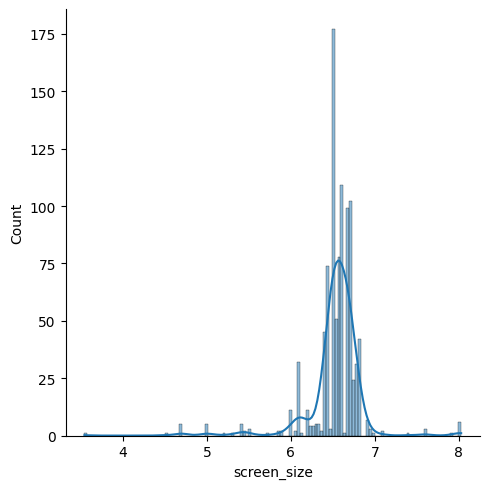

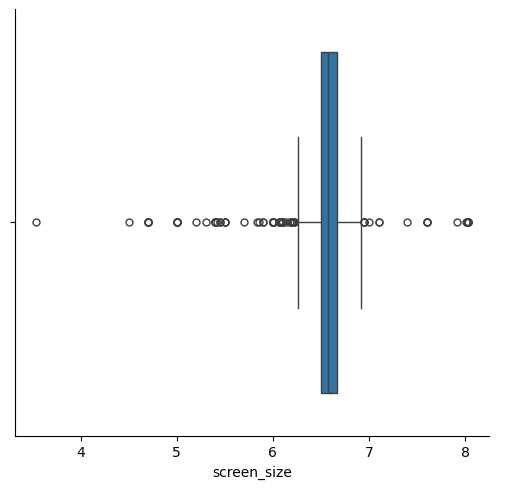

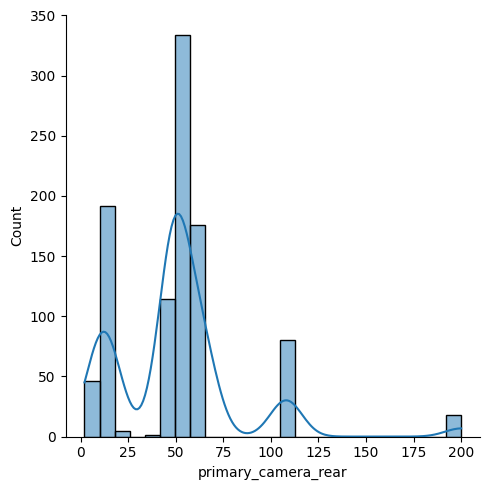

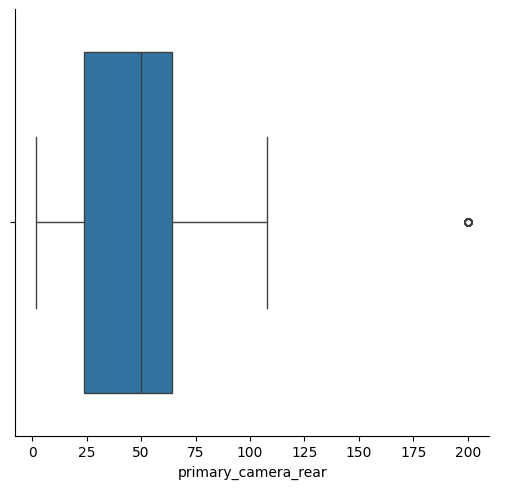

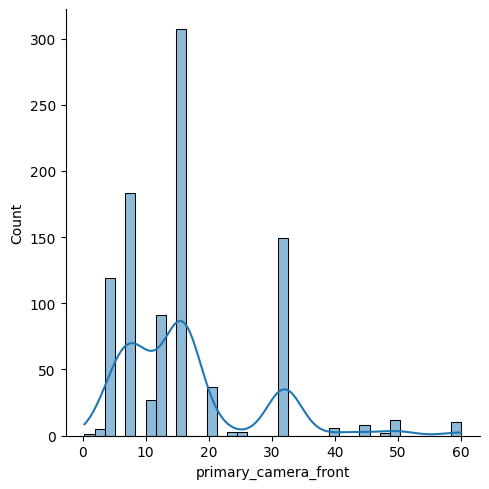

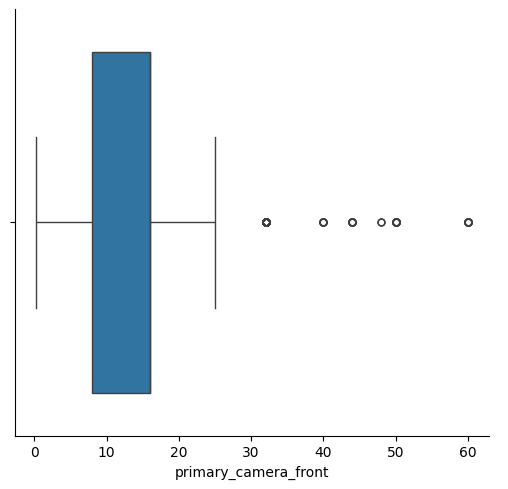

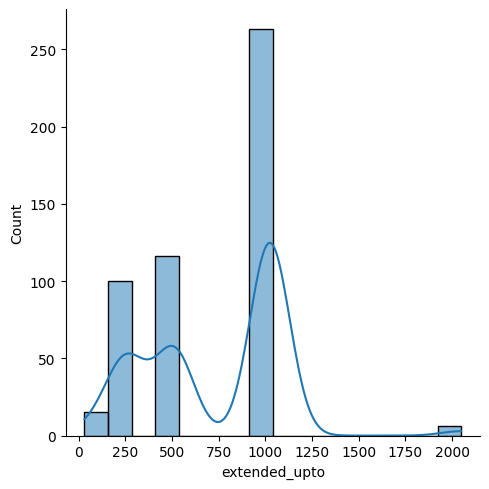

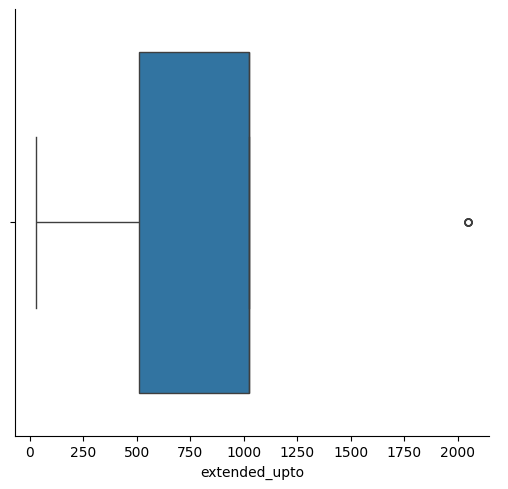

In [82]:
for col in num_columns:
  plot_graphs(col)

#### Bi-Variate Analysis

I have chosen price column as the reference for analysis (output col in my predictor model)

C:\Users\preet\AppData\Local\Temp\ipykernel_384\2463652055.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df,x='brand_name',y='price',palette='autumn')


([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43],
 [Text(0, 0, 'oneplus'),
  Text(1, 0, 'samsung'),
  Text(2, 0, 'motorola'),
  Text(3, 0, 'realme'),
  Text(4, 0, 'apple'),
  Text(5, 0, 'xiaomi'),
  Text(6, 0, 'nothing'),
  Text(7, 0, 'oppo'),
  Text(8, 0, 'vivo'),
  Text(9, 0, 'poco'),
  Text(10, 0, 'iqoo'),
  Text(11, 0, 'jio'),
  Text(12, 0, 'gionee'),
  Text(13, 0, 'tecno'),
  Text(14, 0, 'tesla'),
  Text(15, 0, 'google'),
  Text(16, 0, 'infinix'),
  Text(17, 0, 'cola'),
  Text(18, 0, 'letv'),
  Text(19, 0, 'ikall'),
  Text(20, 0, 'leeco'),
  Text(21, 0, 'duoqin'),
  Text(22, 0, 'nokia'),
  Text(23, 0, 'lava'),
  Text(24, 0, 'honor'),
  Text(25, 0, 'nubia'),
  Text(26, 0, 'redmi'),
  Text(27, 0, 'asus'),
  Text(28, 0, 'itel'),
  Text(29, 0, 'sony'),
  Text(30, 0, 'oukitel'),
  Tex

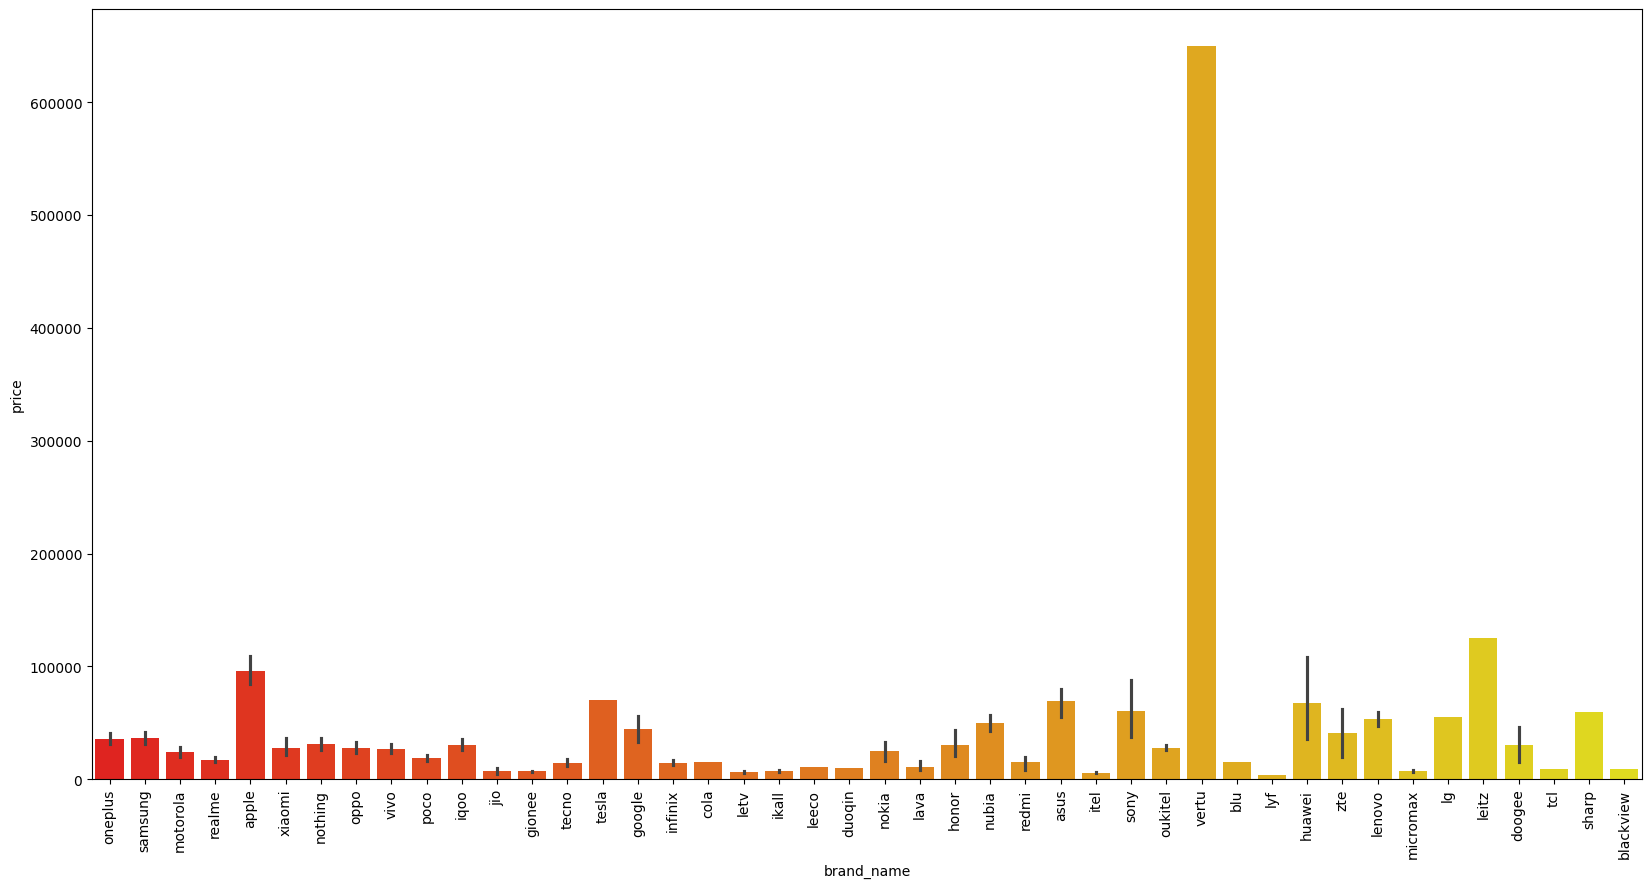

In [91]:
plt.figure(figsize=(20,10))
sns.barplot(data=df,x='brand_name',y='price',palette='autumn')
plt.xticks(rotation='vertical')

In [92]:
x = df.groupby('brand_name').count()['model'] 

In [93]:
temp_df = df[df['brand_name'].isin(x[x > 10].index)]

C:\Users\preet\AppData\Local\Temp\ipykernel_384\1138142605.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=temp_df,x='brand_name',y='price', palette='rainbow')


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15],
 [Text(0, 0, 'oneplus'),
  Text(1, 0, 'samsung'),
  Text(2, 0, 'motorola'),
  Text(3, 0, 'realme'),
  Text(4, 0, 'apple'),
  Text(5, 0, 'xiaomi'),
  Text(6, 0, 'oppo'),
  Text(7, 0, 'vivo'),
  Text(8, 0, 'poco'),
  Text(9, 0, 'iqoo'),
  Text(10, 0, 'tecno'),
  Text(11, 0, 'google'),
  Text(12, 0, 'infinix'),
  Text(13, 0, 'nokia'),
  Text(14, 0, 'honor'),
  Text(15, 0, 'huawei')])

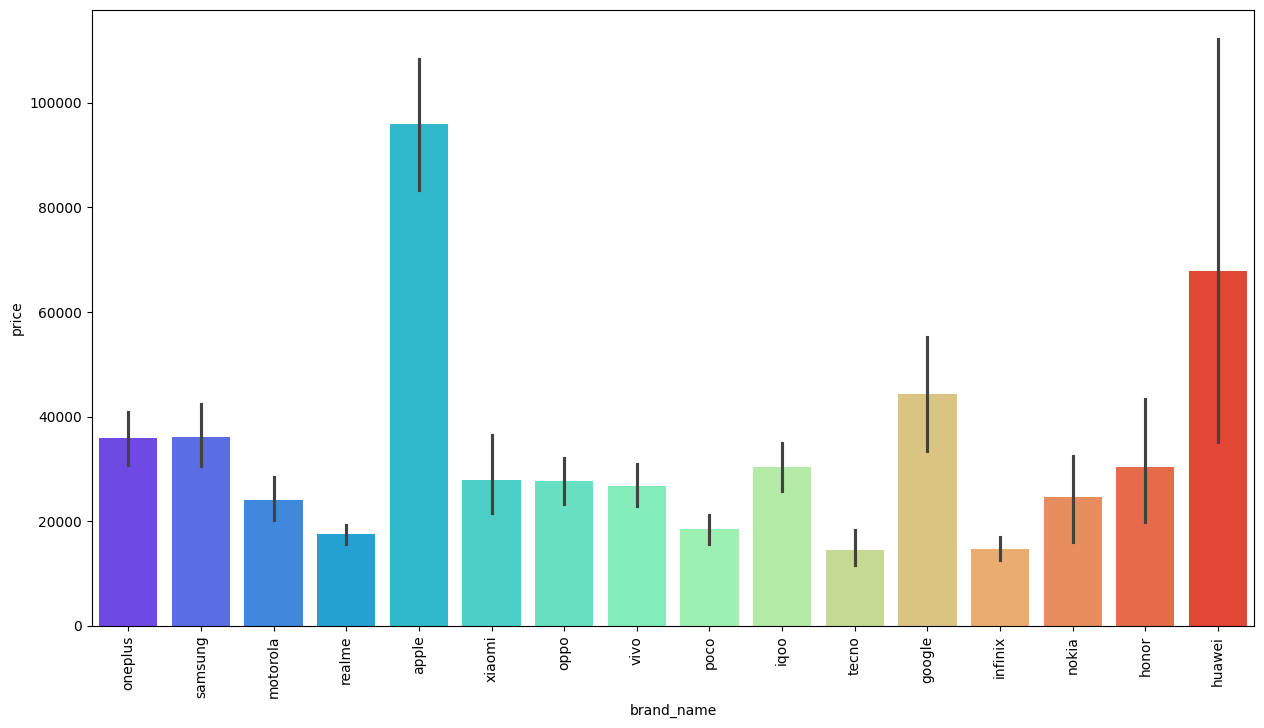

In [96]:
plt.figure(figsize=(15,8))
sns.barplot(data=temp_df,x='brand_name',y='price', palette='rainbow')
plt.xticks(rotation='vertical')

<Axes: xlabel='rating', ylabel='price'>

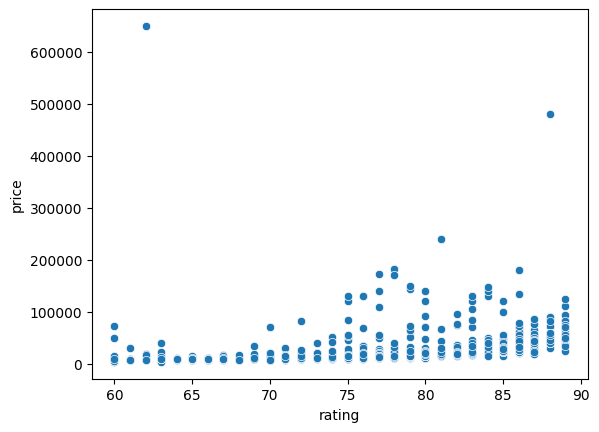

In [110]:
sns.scatterplot(data=df,x='rating',y='price')
# adding hue='brand_name' will make it a multi-variate analysis - can do if req

<Axes: xlabel='has_5g', ylabel='price'>

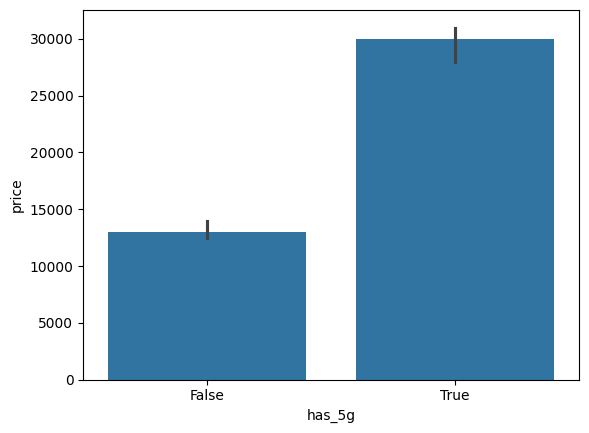

In [ ]:
sns.barplot(data=temp_df,x='has_5g',y='price',estimator=np.median)
# estimator added as mean probably could give weird results due to outliers

<Axes: xlabel='has_nfc', ylabel='price'>

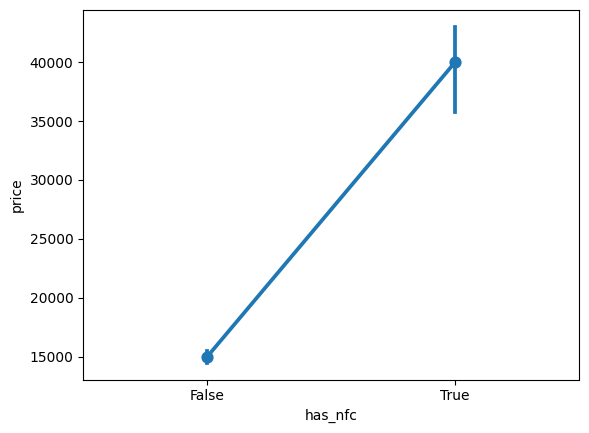

In [ ]:
sns.pointplot(data=temp_df,x='has_nfc',y='price',estimator=np.median)

<Axes: xlabel='has_ir_blaster', ylabel='price'>

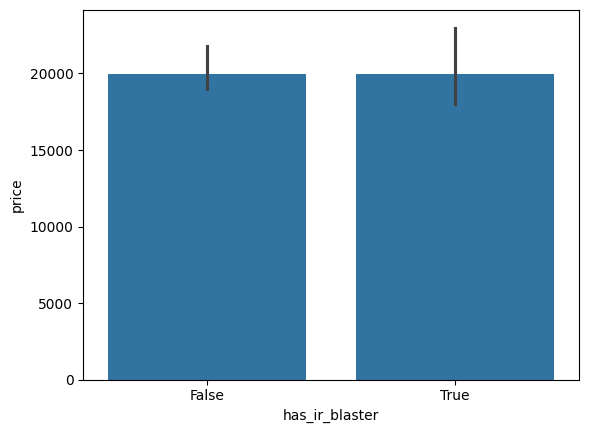

In [ ]:
sns.barplot(data=temp_df,x='has_ir_blaster',y='price',estimator=np.median)
# not quite a major factor in price

C:\Users\preet\AppData\Local\Temp\ipykernel_384\266878478.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=temp_df,x='processor_brand',y='price',estimator=np.median, palette='Set2')


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
 [Text(0, 0, 'snapdragon'),
  Text(1, 0, 'exynos'),
  Text(2, 0, 'dimensity'),
  Text(3, 0, 'bionic'),
  Text(4, 0, 'helio'),
  Text(5, 0, 'unisoc'),
  Text(6, 0, 'google'),
  Text(7, 0, 'tiger'),
  Text(8, 0, 'sc9863a'),
  Text(9, 0, 'fusion'),
  Text(10, 0, 'kirin'),
  Text(11, 0, 'spreadtrum'),
  Text(12, 0, 'mediatek')])

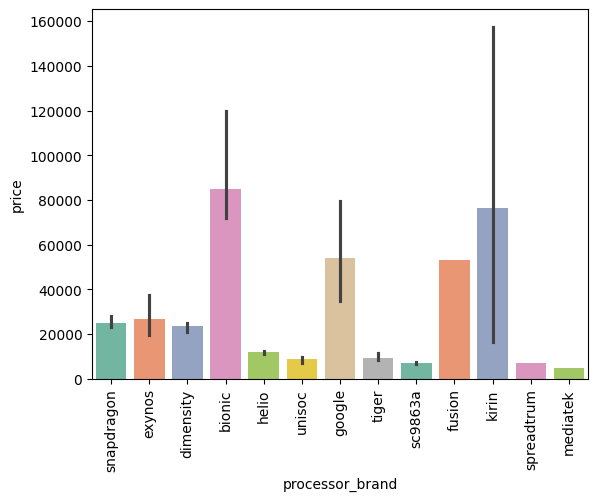

In [102]:
sns.barplot(data=temp_df,x='processor_brand',y='price',estimator=np.median, palette='Set2')
plt.xticks(rotation='vertical')

([0, 1, 2], [Text(0, 0, '4.0'), Text(1, 0, '6.0'), Text(2, 0, '8.0')])

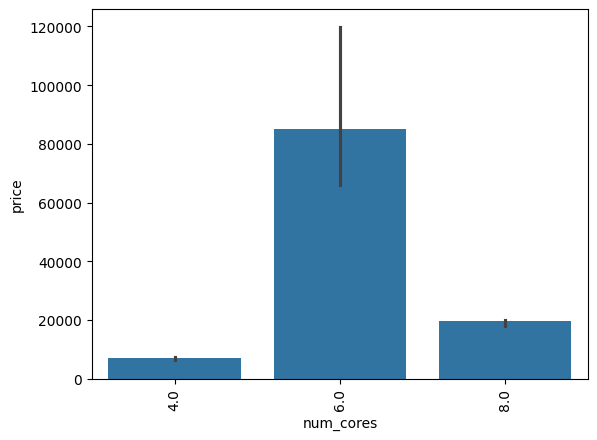

In [103]:
sns.barplot(data=temp_df,x='num_cores',y='price',estimator=np.median)
plt.xticks(rotation='vertical')

In [ ]:
pd.crosstab(df['num_cores'],df['os'])
# ios devices are mostly hexa-core
# so num-cores and os will impart similar impact on prediction to an extent

os,android,ios,other
num_cores,,,
4.0,33,1,1
6.0,0,39,0
8.0,876,1,9


<Axes: xlabel='processor_speed', ylabel='price'>

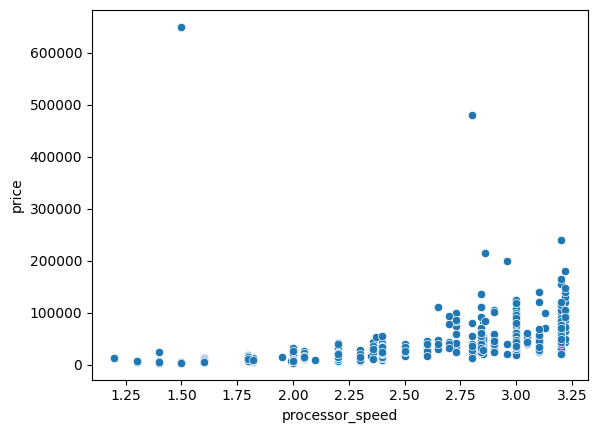

In [105]:
sns.scatterplot(data=df,x='processor_speed',y='price')

<Axes: xlabel='screen_size', ylabel='price'>

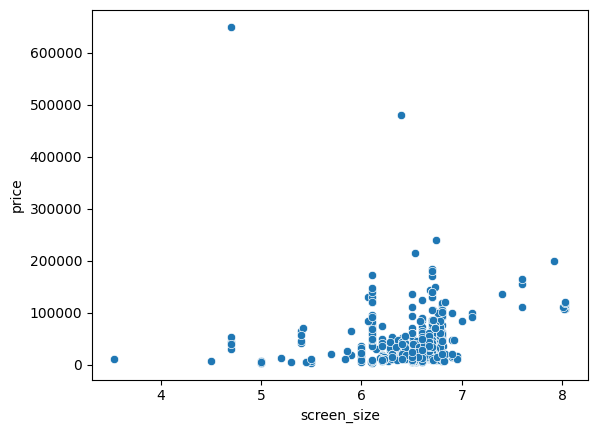

In [106]:
sns.scatterplot(data=df,x='screen_size',y='price')

In [ ]:
df.corr(numeric_only=True)['price']

price                        1.000000
rating                       0.269289
has_5g                       0.300917
has_nfc                      0.469630
has_ir_blaster              -0.025851
num_cores                   -0.058858
processor_speed              0.465072
battery_capacity            -0.156669
fast_charging_available      0.125353
fast_charging                0.284315
ram_capacity                 0.380493
internal_memory              0.550156
screen_size                  0.066908
refresh_rate                 0.249953
num_rear_cameras             0.124924
num_front_cameras            0.073029
primary_camera_rear          0.094680
primary_camera_front         0.157651
extended_memory_available   -0.436726
extended_upto                0.091945
Name: price, dtype: float64

<Axes: >

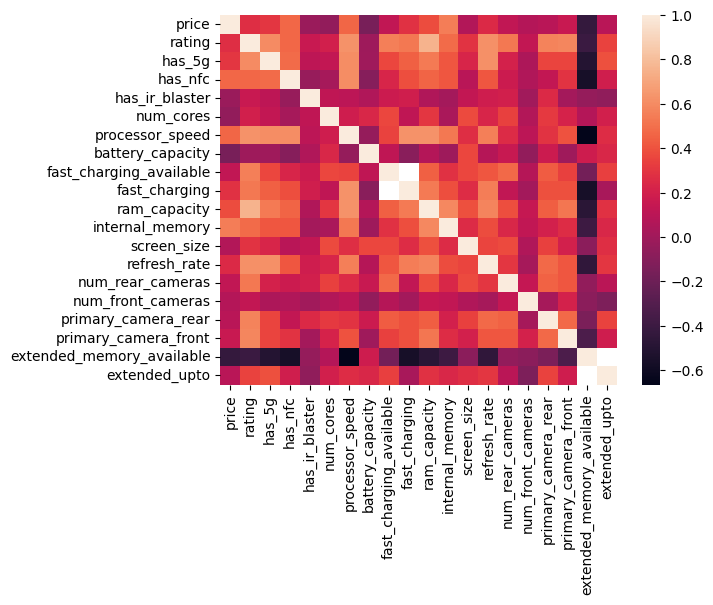

In [ ]:
sns.heatmap(df.corr(numeric_only=True))
# the darker the color, the more correlated the features are and
# hence, you can perform more bivairiate analysis on those features accordingly

In [119]:
df.isnull().sum()
# we will try to fill the rating nulls

brand_name                     0
model                          0
price                          0
rating                        96
has_5g                         0
has_nfc                        0
has_ir_blaster                 0
processor_brand               20
num_cores                      6
processor_speed               42
battery_capacity              11
fast_charging_available        0
fast_charging                206
ram_capacity                   0
internal_memory                0
screen_size                    0
refresh_rate                   0
resolution                     0
num_rear_cameras               0
num_front_cameras              0
os                             0
primary_camera_rear            0
primary_camera_front           3
extended_memory_available      0
extended_upto                466
dtype: int64

In [120]:
# knn imputer
x_df = df.select_dtypes(include=['int64','float64']).drop(columns='price')

In [121]:
from sklearn.impute import KNNImputer

In [122]:
imputer = KNNImputer(n_neighbors=5)

In [123]:
x_df_values = imputer.fit_transform(x_df)

In [124]:
x_df = pd.DataFrame(x_df_values,columns=x_df.columns)

In [126]:
x_df.isnull().sum()

rating                       0
num_cores                    0
processor_speed              0
battery_capacity             0
fast_charging_available      0
fast_charging                0
ram_capacity                 0
internal_memory              0
screen_size                  0
refresh_rate                 0
num_rear_cameras             0
num_front_cameras            0
primary_camera_rear          0
primary_camera_front         0
extended_memory_available    0
extended_upto                0
dtype: int64

In [127]:
x_df['price']= df['price']

In [130]:
a = x_df.corr(numeric_only = True)['price'].reset_index()

In [132]:
b = df.corr(numeric_only=True)['price'].reset_index()

In [ ]:
b.merge(a,on='index')
# side by side comparison of correlation values before and after knn imputation

,index,price_x,price_y
0,price,1.000000,1.000000
1,rating,0.269289,0.326950
2,num_cores,-0.058858,-0.066503
3,processor_speed,0.465072,0.480120
4,battery_capacity,-0.156669,-0.164046
5,fast_charging_available,0.125353,0.125353
6,fast_charging,0.284315,0.226987
7,ram_capacity,0.380493,0.380493
8,internal_memory,0.550156,0.550156
9,screen_size,0.066908,0.066908
